# M3: the three-way type/axis comparison

`PLANssvep_bh_fm100.md` M3: M1 and M2 each tested one edge of a triangle
-- `VKS_Angle`-vs-`orientation_deg` (M1) and `VKS_Angle`-vs-EEG-ramp-angle
(M2). This notebook completes the third edge (`orientation_deg` vs. the
EEG ramp-angle directly), then asks the sharper question all three pieces
make possible: do the three angles agree *jointly*, not just pairwise?

Requires all three datasets per subject (not each pairwise test using its
own maximal overlap) -- checked directly: FM100 ∩ behavioral ∩ EEG
(session 1) is 43 subjects, identical to M2's own FM100 ∩ EEG overlap
(behavioral doesn't further restrict it).

**A design point worth restating up front**: circular-correlation sign is
not comparable across different pairs of angle spaces -- confirmed, not
just suspected, since M2's `VKS_Angle`-vs-ramp-angle pooled r (-0.40) came
out opposite in sign to M1's `VKS_Angle`-vs-`orientation_deg` result
(+0.37). The joint test below uses `mean(|pairwise r|)` rather than a
signed combination for exactly this reason -- a signed mean would let
pairs partially cancel for no principled reason.

In [1]:
import sys
sys.path.append('../scripts')

import fm100_features
import eeg_features

# fm100_features's own import inserts ssveps/scripts at sys.path[0] (it
# needs ssveps' reliability.py) -- ssveps/scripts has its own plotting.py
# too, so re-assert this project's scripts/ first before resolving
# "plotting", or it would silently import ssveps' version instead.
sys.path.insert(0, '../scripts')
import plotting
import type_axis

if '../../beh/scripts' in sys.path:
    sys.path.remove('../../beh/scripts')
sys.path.insert(0, '../../beh/scripts')
for _name in ('loader', 'features'):
    sys.modules.pop(_name, None)
import loader as beh_loader
import features as beh_features

import matplotlib.pyplot as plt
import pandas as pd

fm100_df = fm100_features.fm100_loader.load_fm100_raw()
beh_df = beh_loader.load_behavioral()
troughs = eeg_features.load_subject_troughs()

fm100_pooled = fm100_features.subject_pooled_features(fm100_df)
beh_rows = [{'sub_id': s, **beh_features.subject_shape_features(beh_df, s)} for s in beh_df['sub_id'].unique()]
beh_table = pd.DataFrame(beh_rows)
eeg_session1 = eeg_features.subject_session_features(troughs)
eeg_session1 = eeg_session1[eeg_session1['session'] == 1]

merged = fm100_pooled.merge(beh_table, on='sub_id').merge(eeg_session1, on='sub_id', suffixes=('_fm100', '_eeg'))
print(f"{len(merged)} subjects with FM100, behavioral, and EEG (session 1) data")
merged.groupby(['group_eeg', 'subgroup_eeg'])['sub_id'].nunique()

43 subjects with FM100, behavioral, and EEG (session 1) data


group_eeg  subgroup_eeg
CVD        deutan          7
           protan          8
Name: sub_id, dtype: int64

## Completing the triangle: orientation_deg vs. EEG ramp-angle

In [2]:
triangle_result = type_axis.circular_correlation_test(merged['orientation_deg'].to_numpy(), merged['ramp_angle_deg'].to_numpy())
print(triangle_result)

{'r': -0.22635365825561224, 'p_value': 0.13196320312867102, 'n': 43}


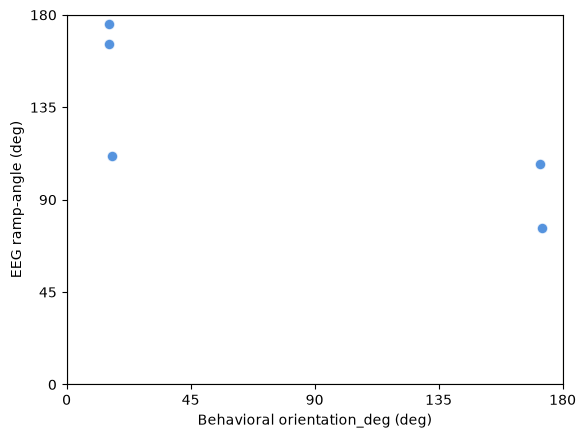

In [3]:
plotting.plot_circular_scatter(merged['orientation_deg'].to_numpy(), merged['ramp_angle_deg'].to_numpy(), x_label='Behavioral orientation_deg (deg)', y_label='EEG ramp-angle (deg)');

**Not significant pooled** (r=-0.23, p=0.13, n=43) -- unlike the other two
edges (M1's r=0.37 p=0.009, M2's r=-0.40 p=0.014), behavioral and EEG
type/axis don't directly correlate with each other on their own. This is
exactly the situation the joint test below is built for: does the
*overall* three-way pattern still carry information even when one specific
edge, taken alone, doesn't reach significance?

## The joint concordance test

In [4]:
angle_arrays = [merged['VKS_Angle'].to_numpy(), merged['orientation_deg'].to_numpy(), merged['ramp_angle_deg'].to_numpy()]
labels = ['FM100', 'Behavioral', 'EEG']

joint_result = type_axis.joint_concordance_test(angle_arrays, n_perm=5000, seed=0)
print(f"statistic (mean |pairwise r|) = {joint_result['statistic']:.3f}, p = {joint_result['p_value']:.4f}")
joint_result['pairwise_r']

statistic (mean |pairwise r|) = 0.333, p = 0.0012


{(0, 1): 0.37524253264959334,
 (0, 2): -0.398173813981156,
 (1, 2): -0.22635365825561224}

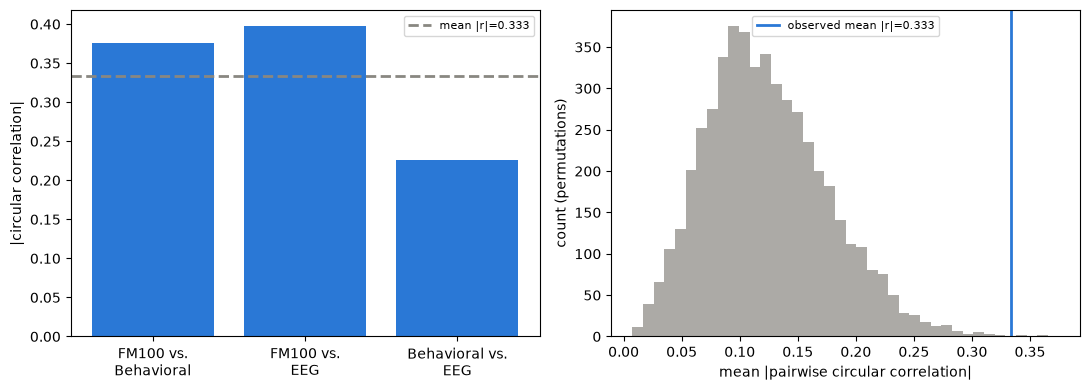

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plotting.plot_pairwise_bars(joint_result, labels, ax=axes[0])
plotting.plot_joint_null_distribution(joint_result, ax=axes[1])
fig.tight_layout()

**Significant pooled** (mean |r|=0.33, p=0.0012) -- **even though one of
the three edges (the one just tested above) isn't significant on its
own.** This is the payoff of the joint test: FM100-vs-behavioral (r=0.38)
and FM100-vs-EEG (r=-0.40) are each individually strong, and together they
carry enough combined signal to clear the joint permutation null even with
behavioral-vs-EEG (r=-0.23) pulling the average down. A pattern spread
across a triangle, not concentrated in one edge, is still real evidence of
a shared underlying axis -- exactly the kind of signal 25 separate
univariate tests (`ssvepBeh/`'s mistake) would have made harder to see, not
easier.

## Per-group breakdown

In [6]:
categories = [
    ('all', merged),
    ('HC', merged[merged.group_eeg == 'CTR']),
    ('PD', merged[merged.group_eeg == 'PD']),
    ('CVD', merged[merged.group_eeg == 'CVD']),
    ('protan', merged[merged.subgroup_eeg == 'protan']),
    ('deutan', merged[merged.subgroup_eeg == 'deutan']),
]

rows = []
for label, sub in categories:
    if len(sub) < 3:
        rows.append({'category': label, 'n': len(sub), 'triangle_r': None, 'triangle_p': None, 'joint_stat': None, 'joint_p': None})
        continue
    t = type_axis.circular_correlation_test(sub['orientation_deg'].to_numpy(), sub['ramp_angle_deg'].to_numpy())
    j = type_axis.joint_concordance_test([sub['VKS_Angle'].to_numpy(), sub['orientation_deg'].to_numpy(), sub['ramp_angle_deg'].to_numpy()], n_perm=2000, seed=0)
    rows.append({'category': label, 'n': len(sub), 'triangle_r': t['r'], 'triangle_p': t['p_value'], 'joint_stat': j['statistic'], 'joint_p': j['p_value']})
pd.DataFrame(rows)

,category,n,triangle_r,triangle_p,joint_stat,joint_p
0,all,43,-0.226354,0.131963,0.333257,0.001499
1,HC,21,0.315299,0.147731,0.261145,0.139930
2,PD,6,0.097487,0.821094,0.351060,0.550725
3,CVD,15,-0.076444,0.765106,0.212575,0.473763
4,protan,8,-0.568495,0.023132,0.487148,0.083458
5,deutan,7,-0.316405,0.471839,0.364034,0.406797


**No group reaches significance on the joint test alone** -- same pattern
M1/M2 already found for the severity CCA: the pooled result is real, but
per-group samples (n=6-21) aren't yet large enough to confirm it holds
within any single diagnostic category. One notable exception on the
*pairwise* triangle-completion test specifically: **`protan` alone shows a
significant `orientation_deg`-vs-EEG-ramp-angle correlation** (r=-0.57,
p=0.023, n=8) -- the opposite of the pooled non-result, and a genuinely new
lead, though thin enough at n=8 to treat as worth re-testing with more
protan subjects rather than a confirmed finding.

## Summary

- **Triangle completed**: `orientation_deg` vs. EEG ramp-angle is *not*
  significant pooled (r=-0.23, p=0.13) -- the one edge of the triangle that
  doesn't hold up on its own.
- **Joint concordance across all three angles is significant pooled**
  (p=0.0012) despite that missing edge -- real evidence that FM100,
  behavioral, and EEG type/axis measures share underlying structure as a
  *system*, not just pairwise. This is the strongest whole-project argument
  yet for your original "masked continuous spectrum" hypothesis: it shows
  up not in one measurement, but consistently enough across three
  independent instruments that a joint test built to be robust to any one
  weak edge still finds it.
- **No single group confirms the joint result on its own** at current
  sample sizes -- protan's own triangle-completion edge (n=8, p=0.023) is
  a new, specific lead worth flagging for more data, not yet a finding.
- Next: more CVD/protan/deutan subjects remains the standing
  recommendation across this entire project. On the methods side, nothing
  further is obviously missing from this specific analysis -- the joint
  test does what M3 set out to do.